In [44]:
### Labels for stacked bar

# # negative offset.
# y_offset = -5
# # For each patch (basically each rectangle within the bar), add a label.
# for bar in ax.patches:
#   ax.text(
#       # Put the text in the middle of each bar. get_x returns the start
#       # so we add half the width to get to the middle.
#       bar.get_x() + bar.get_width() / 2,
#       # Vertically, add the height of the bar to the start of the bar,
#       # along with the offset.
#       bar.get_height() + bar.get_y() + y_offset,
#       # This is actual value we'll show.
#       round(bar.get_height()),
#       # Center the labels and style them a bit.
#       ha='center',
#       color='black',
#       #weight='bold',
#       size=10)


### saving legend as separate figure
# import numpy as np
# from matplotlib import pyplot as plt
# x = np.linspace(1, 100, 1000)
# y = np.log(x)
# y1 = np.sin(x)
# fig = plt.figure("Line plot")
# legendFig = plt.figure("Legend plot")
# ax = fig.add_subplot(111)
# line1, = ax.plot(x, y, c="red", lw=4, linestyle="dashdot")
# line2, = ax.plot(x, y1, c="green", lw=1, linestyle="--")
# legendFig.legend([line1, line2], ["y=log(x)", "y=sin(x)"], loc='center')
# legendFig.savefig('legend.png')

###### Imports and Settings

In [45]:
import pandas as pd
import numpy as np
import requests
import io
import pickle
import dataframe_image as dfi
from collections import deque
from functools import reduce
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import StrMethodFormatter
from matplotlib import rcParams
import matplotlib as mpl
from matplotlib.axis import Axis
from matplotlib.patches import FancyBboxPatch
import datetime 
from matplotlib.dates import DayLocator, HourLocator, DateFormatter, drange 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 150)
pd.options.mode.chained_assignment = None  # default='warn'
def percentformatter(elements):
    for i in elements:
        df_temp['{}'.format(i)] = df_temp['{}'.format(i)]*100

In [181]:
data = pd.read_csv('../../data/Geography Specific Output/GallatinFigures.csv')
data['Year'] = data['Year'].replace('None','0')
data['Year'] = data['Year'].astype(float)
data.tail(30)

NAME    Year Time Frame  Age %:Under 5  Age %:Under 5 % Change  Age %:Under 5 Change  Age%:10 to 14  Age%:10 to 14 % Change  \
0   Sumner County  2000.0       None       0.067712                     NaN                   NaN       0.075508                     NaN   
1   Sumner County  2010.0       None       0.065156                     NaN                   NaN       0.073634                     NaN   
2   Sumner County  2020.0       None       0.060166                     NaN                   NaN       0.063853                     NaN   
3   Sumner County     0.0  2000-2010            NaN               -3.775085             -0.002556            NaN               -2.481875   
4   Sumner County     0.0  2000-2020            NaN              -11.144278             -0.007546            NaN              -15.435453   
5   Sumner County     0.0  2010-2020            NaN               -7.658300             -0.004990            NaN              -13.283251   
6        Gallatin  2000.0       None       0.073181                     NaN                   NaN       0.069522                     NaN   
7        Gallatin  2010.0       None       0.074708                     NaN                   NaN       0.062653                     NaN   
8        Gallatin  2020.0       None       0.061075                     NaN                   NaN       0.060628                     NaN   
9        Gallatin     0.0  2000-2010            NaN                2.085886              0.001526            NaN               -9.880903   
10       Gallatin     0.0  2000-2020            NaN              -16.542865             -0.012106            NaN              -12.793448   
11       Gallatin     0.0  2010-2020            NaN              -18.248116             -0.013633            NaN               -3.231883   
12      Tennessee  2000.0       None       0.065892                     NaN                   NaN       0.069456                     NaN   
13      Tennessee  2010.0       None       0.064262                     NaN                   NaN       0.066015                     NaN   
14      Tennessee  2020.0       None       0.060096                     NaN                   NaN       0.064364                     NaN   
15      Tennessee     0.0  2000-2010            NaN               -2.474300             -0.001630            NaN               -4.953601   
16      Tennessee     0.0  2000-2020            NaN               -8.796690             -0.005796            NaN               -7.330927   
17      Tennessee     0.0  2010-2020            NaN               -6.482794             -0.004166            NaN               -2.501227   
18             US  2000.0       None       0.068139                     NaN                   NaN       0.072944                     NaN   
19             US  2010.0       None       0.065430                     NaN                   NaN       0.066972                     NaN   
20             US  2020.0       None       0.060172                     NaN                   NaN       0.064635                     NaN   
21             US     0.0  2000-2010            NaN               -3.974978             -0.002709            NaN               -8.187746   
22             US     0.0  2000-2020            NaN              -11.692846             -0.007967            NaN              -11.390639   
23             US     0.0  2010-2020            NaN               -8.037351             -0.005259            NaN               -3.488525   
24    GNRC Region  2000.0       None       0.070051                     NaN                   NaN       0.069929                     NaN   
25    GNRC Region  2010.0       None       0.071139                     NaN                   NaN       0.067287                     NaN   
26    GNRC Region  2020.0       None       0.065275                     NaN                   NaN       0.066413                     NaN   
27    GNRC Region     0.0  2000-2010            NaN                1.553632              0.00

## Presets

In [183]:
#time or timeframe
distinctyear = data.loc[data['Year'] != 0]
timespan = data.loc[data['Year'] == 0]
current = data.loc[data['Year'] == 2020.0]
twothousandtotwentytwenty = data.loc[data['Time Frame'] == '2000-2020']
#geography groups
#geography of interest
gallatin = data.loc[data['NAME'] == 'Gallatin']
#county and place
sumner = data.loc[data['NAME'] == 'Sumner County']
#all geographies
allgeos = countyandplace = data.loc[(data['NAME'] == 'US') | (data['NAME'] == 'Tennessee')| 
                                    (data['NAME'] == 'GNRC Region') | (data['NAME'] == 'Sumner County')| 
                                    (data['NAME'] == 'Gallatin')]
#citation options
alldecennial = 'Citation: 2000, 2010, and 2020 Decennial Census'
sf32010acs2020acs = 'Citation: 2000 Decennial Census, 2010 2020 American Community Survey 5 Year Estimates'
#axis label formatting options
yearformat = '%.0f'
numbernodecimalformat = '{x:,.0f}'
percentformat = '{x:,.0f}%'
#dpi
dpi = 500
#grid parameters and white facecolor
gridlinestyle = '-'
gridlinewidth = '0.5'
gridcolor = '#6DB0C7'
facecolor = '#FFFFFF'
linealpha = 0.5 #Line Transparency
linewidth = 3 #Line Width
marker = 'o' #Circles on Points
linecolor1 = '#00263E' #GNRC Grey
linecolor2 = '#EB7525' #GNRC Orange
GNRCOrange = '#EB7525'
GNRCBlue = '#00263E'
barcolor1 = '#00263E' #GNRC Dark Blue
barcolor2 = '#00263E' #GNRC Grey
#tick label parameters
tickaxisselection = 'both'
majororminortick = 'major'
ticklabelpadding = 5
#font stuff
SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 18
BIGGEST_SIZE = 20
plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('axes', titlesize=BIGGEST_SIZE)  # fontsize of the figure title
rcParams['font.family'] = 'calibri'
#axes labels etc.
COLOR = '#00263E'
mpl.rcParams['text.color'] = COLOR
mpl.rcParams['axes.labelcolor'] = COLOR
mpl.rcParams['axes.labelpad'] = 15
mpl.rcParams['axes.titlepad'] = 20
mpl.rcParams['xtick.color'] = COLOR
mpl.rcParams['ytick.color'] = COLOR

# Narrative Category: Population  

## Figure Title: Comparative Population Over Time

In [221]:
title = 'Comparative Population\n 2000 to 2020' #set title of figure
figsize = (10, 5) #set figure size
#df_temp1 = distinctyear
df_temp1 = gallatin #set geo for line 1
x1input = 'Year' #set string for axis label and column input for x
y1input = 'Population' #set string for axis label and column input for y
x1 = df_temp1[x1input] #set x for line 1
y1 = df_temp1[y1input] #set y for line 1
xlabel = x1input #set x label
ylabel = y1input #set y label
linelabel1 = 'Gallatin'
df_temp2 = sumner #set geo for line 1
x2input = 'Year' #set string for axis label and column input for x
y2input = 'Population' #set string for axis label and column input for y
x2 = df_temp2[x2input] #set x for line 2
y2 = df_temp2[y2input] #set y for line 2
xlabel = x2input #set x label
ylabel = y2input #set y label
linelabel2 = 'Sumner County'
xaxislabelformat = yearaxisformatter #set x axis float to be formatted as a year
yaxislabelformat = numbernodecimalaxisformatter #set y axis flot to be formatted with thousandth commas and no decimals
#ylimlow =  #set the low limit for the y axis
#ylimhigh =  #set the high limit for the y axis
citation = alldecennial #set the citation
lines = [(x1, y1), (x2, y2)] #set list of tuples for label for loop

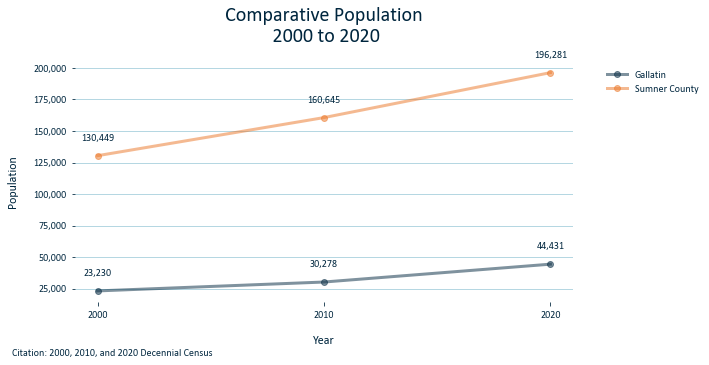

In [226]:
fig, ax = plt.subplots(figsize = figsize)
ax.plot(x1, y1, marker = marker, color = linecolor1, alpha = linealpha, linewidth = linewidth, label = linelabel1)
ax.plot(x2, y2, marker = marker, color = linecolor2, alpha = linealpha, linewidth = linewidth, label = linelabel2)
ax.set(title = title, xlabel = xlabel, ylabel = ylabel) #set the title and axes labels
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(xaxislabelformat)) #x axis formatting
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(yaxislabelformat)) #y axis formatting
ax.yaxis.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
#ax.set_ylim(ylimlow, ylimhigh) #y low and high limits
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
ax.set_alpha(0)
plt.locator_params(axis='x', nbins=3)
ax.legend(loc = 7, facecolor = facecolor)#, bbox_to_anchor=(1, -.3)) #legend
#citation label
fig.text(.3, .0009, citation, ha='right')
#labels loop
for x_s, y_s in lines:
    for j, k in zip(x_s, y_s):
        label = "{:,.0f}".format(k)
        plt.annotate(label, 
                     (j, k), 
                     textcoords = 'offset points', 
                     xytext = (0, 15), 
                     ha = 'center')
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
#outside legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon = False)
fig.tight_layout()
fig.savefig('gallatinfigstables/comparativepopulationovertime.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

## Figure Title: Comparative Percent Change in Historic Population  
**add historical data**

In [186]:
title = 'Comparative Percent Change in Historic Population\n 2000 - 2020'
figsize = (10, 5) #set figure size
df_temp1 = twothousandtotwentytwenty
df_temp1 = df_temp1.set_index('NAME')
#order index for figure appearance
new_index = ['US', 'Tennessee', 'GNRC Region', 'Sumner County', 'Gallatin']
df_temp1 = df_temp1.reindex(new_index)
df_temp1 = df_temp1.reset_index()
x1 = df_temp1['NAME']
y1 = df_temp1['Population % Change']
xlabel = 'Geography'
ylabel = 'Percent Change in Population'
yaxislabelformat = percentaxisformatter #set y axis flot to be formatted with thousandth commas and no decimals
ylimlow = 0
ylimhigh = 100
citation = 'Citation: 2000 and 2020 Decennial Census'

In [187]:
#df_temp1.head()

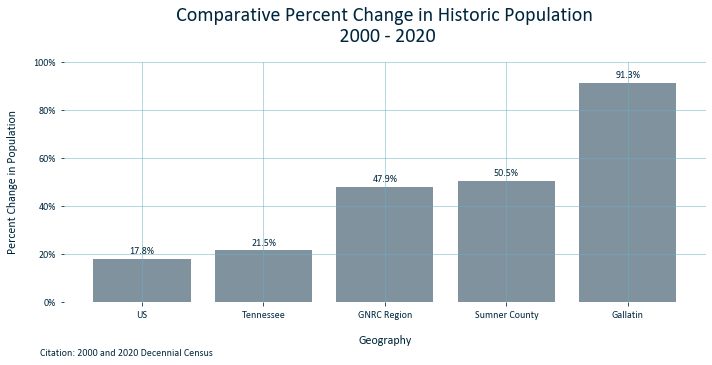

In [188]:
fig, ax = plt.subplots(figsize = figsize)
ax.bar(x1, y1, color = barcolor1, alpha = linealpha) 
ax.set(title = title, xlabel = xlabel, ylabel = ylabel) #set the title and axes labels
#ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(xaxislabelformat)) #x axis formatting
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(yaxislabelformat)) #y axis formatting
ax.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
ax.set_ylim(ylimlow, ylimhigh) #y low and high limits
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
ax.set_alpha(0)
#citation label
fig.text(.3, .0009, citation, ha='right')
for j, k in zip(x1, y1):
    label = "{:,.1f}%".format(k)
    plt.annotate(label, 
                (j, k), 
                textcoords = 'offset points', 
                xytext = (0, 5), 
                ha = 'center')
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
fig.tight_layout()
fig.savefig('gallatinfigstables/comparativehistoricpopulationgrowth.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

skipping a few projection related figures for the moment

## Figure Title: Population Pyramid

In [189]:
title = 'Population Pyramid'
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[df_temp['Year'] == 2020.0]
df_temp1 = df_temp[['Male Under 5', 'Male 5 to 14', 'Male 15 to 24', 'Male 25 to 34', 'Male 35 to 44', 'Male 45 to 54', 
                     'Male 55 to 64', 'Male 65 to 74', 'Male 75 to 84', 'Male 85 and Older']]
df_temp1_transp = df_temp1.transpose().reset_index()
df_temp1_transp.columns = ['Age Group', 'Male Population']
splittitle = df_temp1_transp['Age Group'].str.split(" ", 1, expand = True)
df_temp1_transp['Age Group'] = splittitle[1]
df_temp2 = df_temp[['Female Under 5', 'Female 5 to 14', 'Female 15 to 24', 'Female 25 to 34', 'Female 35 to 44', 'Female 45 to 54', 
                     'Female 55 to 64', 'Female 65 to 74', 'Female 75 to 84', 'Female 85 and Older']]
df_temp2_transp = df_temp2.transpose().reset_index()
df_temp2_transp.columns = ['Age Group', 'Female Population']
splittitle = df_temp2_transp['Age Group'].str.split(" ", 1, expand = True)
df_temp2_transp['Age Group'] = splittitle[1]
df_temp = df_temp1_transp.merge(df_temp2_transp, on = 'Age Group')
citation = 'Citation: 2000 and 2010 Decennial Census, 2016-2020 ACS 5 Year Estimate'

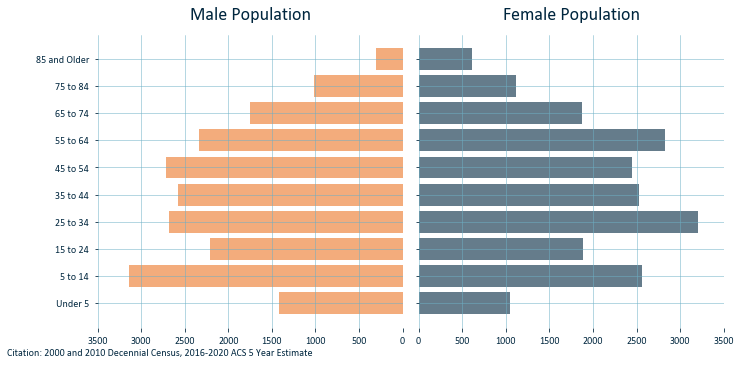

In [190]:
fig, axes = plt.subplots(figsize=figsize, ncols=2, sharey=True)
index = df_temp['Age Group']
indices = [df_temp['Age Group'], df_temp['Age Group']]
column0 = df_temp['Male Population']
column1 = df_temp['Female Population']
columns = [df_temp['Male Population'], df_temp['Female Population']]
axes[0].barh(index, column0, align='center', color= GNRCOrange, alpha = 0.6)
axes[0].set_title('Male Population', fontsize=18, pad=15)
axes[0].set_xlim(0, 3500)
axes[0].invert_xaxis() 
axes[1].barh(index, column1, align='center', color= GNRCBlue, alpha = 0.6)
axes[1].set_title('Female Population', fontsize=18, pad=15)
axes[1].set_xlim(0, 3500)
axes[0].set_facecolor(color = 'None') #facecolor
axes[0].set_alpha(0)
axes[1].set_facecolor(color = 'None') #facecolor
axes[1].set_alpha(0)
#citation label
fig.text(.4, .000001, citation, ha='right')
axes[0].grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
axes[1].grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
axes[0].tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
axes[1].tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
#take away box
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['bottom'].set_visible(False)
axes[0].spines['left'].set_visible(False)
#take away box
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['bottom'].set_visible(False)
axes[1].spines['left'].set_visible(False)
fig.tight_layout()
fig.savefig('gallatinfigstables/populationpyramid.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

## Figure Title: Population Breakout: Under 18

In [191]:
data.head()

,NAME,Year,Time Frame,Age %:Under 5,Age %:Under 5 % Change,Age %:Under 5 Change,Age%:10 to 14,Age%:10 to 14 % Change,Age%:10 to 14 Change,Age%:15 to 17,Age%:15 to 17 % Change,Age%:15 to 17 Change,Age%:18 to 24,Age%:18 to 24 % Change,Age%:18 to 24 Change,Age%:18 to 54,Age%:18 to 54 % Change,Age%:18 to 54 Change,Age%:25 to 34,Age%:25 to 34 % Change,Age%:25 to 34 Change,Age%:35 to 44,Age%:35 to 44 % Change,Age%:35 to 44 Change,Age%:45 to 54,Age%:45 to 54 % Change,Age%:45 to 54 Change,Age%:5 to 9,Age%:5 to 9 % Change,Age%:5 to 9 Change,Age%:55 and Older,Age%:55 and Older % Change,Age%:55 and Older Change,Age%:55 to 64,Age%:55 to 64 % Change,Age%:55 to 64 Change,Age%:65 and Older,Age%:65 and Older % Change,Age%:65 and Older Change,Age%:65 to 74,Age%:65 to 74 % Change,Age%:65 to 74 Change,Age%:75 to 84,Age%:75 to 84 % Change,Age%:75 to 84 Change,Age%:85 and Older,Age%:85 and Older % Change,Age%:85 and Older Change,Age%:Under 18,Age%:Under 18 % Change,Age%:Under 18 Change,Age:10 to 14,Age:10 to 14 % Change,Age:10 to 14 Change,Age:15 to 17,Age:15 to 17 % Change,Age:15 to 17 Change,Age:18 to 24,Age:18 to 24 % Change,Age:18 to 24 Change,Age:18 to 54,Age:18 to 54 % Change,Age:18 to 54 Change,Age:25 to 34,Age:25 to 34 % Change,Age:25 to 34 Change,Age:35 to 44,Age:35 to 44 % Change,Age:35 to 44 Change,Age:45 to 54,Age:45 to 54 % Change,Age:45 to 54 Change,Age:5 to 9,Age:5 to 9 % Change,Age:5 to 9 Change,Age:55 and Older,Age:55 and Older % Change,Age:55 and Older Change,Age:55 to 64,Age:55 to 64 % Change,Age:55 to 64 Change,Age:65 and Older,Age:65 and Older % Change,Age:65 and Older Change,Age:65 to 74,Age:65 to 74 % Change,Age:65 to 74 Change,Age:75 to 84,Age:75 to 84 % Change,Age:75 to 84 Change,Age:85 and Older,Age:85 and Older % Change,Age:85 and Older Change,Age:Under 18,Age:Under 18 % Change,Age:Under 18 Change,Age:Under 5,Age:Under 5 % Change,Age:Under 5 Change,American Indian Alaska Native Alone,American Indian Alaska Native Alone %,American Indian Alaska Native Alone % % Change,American Indian Alaska Native Alone % Change,American Indian Alaska Native Alone % Non-White Population,American Indian Alaska Native Alone % Non-White Population % Change,American Indian Alaska Native Alone % Non-White Population Change,American Indian Alaska Native Alone Change,Asian Alone,Asian Alone %,Asian Alone % % Change,Asian Alone % Change,Asian Alone % Non-White Population,Asian Alone % Non-White Population % Change,Asian Alone % Non-White Population Change,Asian Alone Change,Average Household Size,Average Household Size % Change,Average Household Size Change,Black or African American Alone,Black or African American Alone %,Black or African American Alone % % Change,Black or African American Alone % Change,Black or African American Alone % Non-White Population,Black or African American Alone % Non-White Population % Change,Black or African American Alone % Non-White Population Change,Black or African American Alone Change,CB%: Cost Burdened Homeowners,CB%: Cost Burdened Homeowners % Change,CB%: Cost Burdened Homeowners Change,CB%:Cost Burdened Renters,CB%:Cost Burdened Renters % Change,CB%:Cost Burdened Renters Change,CB%:Severe Cost Burdened Households,CB%:Severe Cost Burdened Households % Change,CB%:Severe Cost Burdened Households Change,CB:Cost Burdened Homeowners,CB:Cost Burdened Homeowners % Change,CB:Cost Burdened Homeowners Change,CB:Cost Burdened Housholds,CB:Cost Burdened Housholds % Change,CB:Cost Burdened Housholds Change,CB:Cost Burdened Renters,CB:Cost Burdened Renters % Change,CB:Cost Burdened Renters Change,CB:Owner Occupied Units,CB:Owner Occupied Units % Change,CB:Owner Occupied Units Change,CB:Renter Occupied Units,CB:Renter Occupied Units % Change,CB:Renter Occupied Units Change,CB:Severe Cost Burdened Households,CB:Severe Cost Burdened Households % Change,CB:Severe Cost Burdened Households Change,CB:Total Housing Units,CB:Total Housing Units % Change,CB:Total Housing Units Change,Commute:10 to 14 Minutes,Commute:15 to 19 Minutes

In [192]:
#table multiple datapoints over time for one geography data prep
citation = 'Citation: 2000 and 2010 Decennial Census, 2016-2020 ACS 5 Year Estimate' #set the citation
df_temp = gallatin
df_temp = df_temp.loc[(df_temp['Time Frame'] == 'None')|(df_temp['Time Frame'] == '2010-2020')]
df_temp = df_temp[['Year', 'Time Frame','Age:Under 5', 'Age:5 to 9','Age:10 to 14','Age:15 to 17', 'Age:Under 5 % Change', 'Age:5 to 9 % Change', 
                    'Age:10 to 14 % Change', 'Age:15 to 17 % Change']]
df_temp = df_temp.replace(0.0, '2010-2020 % Change')
# df_temp = df_temp.set_index('Year')
# df_temp.update(df_temp[['White Alone %', 'Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
#                         'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population', 
#                         'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']].applymap('{:,.1f}%'.format))
# df_temp.update(df_temp[['White Alone', 'Black or African American Alone', 'American Indian Alaska Native Alone',
#                         'Asian Alone', 'Native Hawaiian Other Pacific Islander Alone', 
#                         'Some Other Race Alone', 'Two or More Races']].applymap('{:,.0f}'.format))
#df_temp = df_temp.transpose()

In [193]:
df_temp.head(20)

,Year,Time Frame,Age:Under 5,Age:5 to 9,Age:10 to 14,Age:15 to 17,Age:Under 5 % Change,Age:5 to 9 % Change,Age:10 to 14 % Change,Age:15 to 17 % Change
6,2000.0,None,1700.0,1566.0,1615.0,1014.0,NaN,NaN,NaN,NaN
7,2010.0,None,2262.0,2072.0,1897.0,1099.0,NaN,NaN,NaN,NaN
8,2020.0,None,2459.0,3268.0,2441.0,1133.0,NaN,NaN,NaN,NaN
11,2010-2020 % Change,2010-2020,NaN,NaN,NaN,NaN,8.709107,57.722008,28.676858,3.093722


KeyError: "['Age:Under 5 2000'] not in index"

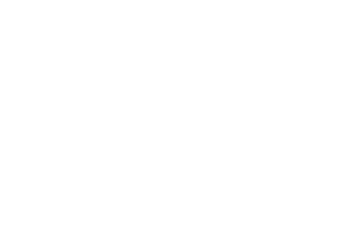

In [194]:
citation = 'Citation: 2000, 2010, and 2020 Decennial Census'
title = 'Breakout: Population Under 18'
width = 5
geographycount = 11
# def getcellcolors(width, height):
#     return:
#     colours = 
colours = [["#E1EFF2" for x in range(width)],["#FFFFFF" for x in range(width)],["#E1EFF2" for x in range(width)],["#FFFFFF" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#FFFFFF" for x in range(width)],["#E1EFF2" for x in range(width)],["#FFFFFF" for x in range(width)],
           ["#E1EFF2" for x in range(width)],["#FFFFFF" for x in range(width)],["#E1EFF2" for x in range(width)]]
colcolours = ['#E1EFF2' for x in range(width)]
rowcolours = ["#FFFFFF" for x in range(geographycount)]
#title height
y = 1.3
#table scaling
tablex = 2
tabley = 2.5
#citation placement
c1 = .1
c2 = -.2
#initiate figure and hide axes
fig, ax = plt.subplots()
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')
#data and formatting
df = data[['Age:Under 5 2000', 'Age:Under 5 2000', 'Age:5 to 9', 'Age:10 to 14', 'Age:15 to 17']]
df['% Change 2000 to 2020'] = prettypercentchange(data['Population 2020'], data['Population 2000'])
df['% Change 2010 to 2020'] = prettypercentchange(data['Population 2020'], data['Population 2010'])
df.update(df[['Population 2000', 'Population 2010', 'Population 2020']].applymap('{:,.0f}'.format))
#initiate table and set parameters
table = ax.table(cellText = df.values, colLabels = df.columns, rowLabels = df.index, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', rowColours = rowcolours)
ax.set_title(label = title, y = y)
table.scale(tablex, tabley)
fig.text(c1, c2, citation, ha='right')
#display
fig.savefig('gallatinfigstables/fig1_populationtable.png', bbox_inches='tight', dpi = dpi)
plt.show()

## Figure Title: Non-White Population Over Time: Plot and Table

In [195]:
citation = alldecennial #set the citation
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[df_temp['Year'] != 0.0]
df_temp = df_temp[['Year','Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
                   'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population',
                   'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']]
elements = ['Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
                   'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population',
                   'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']
percentformatter(elements)
df_temp.columns = ['Year','Black/African American', 'American Indian/Alaska Native',
                   'Asian', 'Native Hawaiian/Other Pacific Islander', 
                   'Some Other Race', 'Two or More Races']
df_temp = df_temp.set_index('Year')

In [196]:
df_temp.head()

,Black/African American,American Indian/Alaska Native,Asian,Native Hawaiian/Other Pacific Islander,Some Other Race,Two or More Races
Year,,,,,,
2000.0,80.956159,1.388613,1.944059,0.317397,9.303710,6.090061
2010.0,65.680911,1.301198,3.415644,0.665385,19.621470,9.315393
2020.0,50.359547,1.621787,5.760404,0.229498,15.185129,26.843635


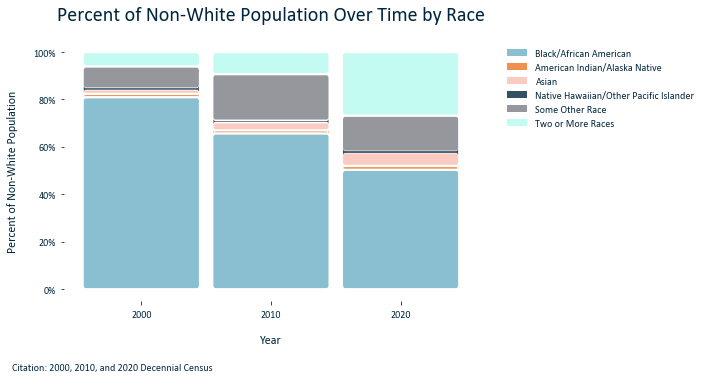

In [197]:
alpha = 0.6 #Line Transparency
fig, ax = plt.subplots(figsize = (10, 5))
w = 9
colors = ['#6DB0C7', '#EB7525', '#F9BFB4', '#00263E', '#7B7E85', '#B4F9EF']
bottom = np.zeros(len(df_temp))
for i, col in enumerate(df_temp.columns):
  ax.bar(df_temp.index, df_temp[col], w, bottom=bottom, label=col, color = colors[i], alpha = 0.8)
  bottom += np.array(df_temp[col])
#rounded boxes
new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color=patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),abs(bb.width), abs(bb.height),boxstyle="round,pad=-0.060,rounding_size=0.15",
                            ec="none", fc=color,mutation_aspect=8)
    patch.remove()
    new_patches.append(p_bbox)
for patch in new_patches:
    ax.add_patch(patch) 
plt.locator_params(axis='x', nbins=4)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(yaxislabelformat)) #y axis formatting
#ax.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
ax.set_alpha(0)
ax.set(title = 'Percent of Non-White Population Over Time by Race', xlabel = 'Year', ylabel = 'Percent of Non-White Population') #set the title and axes labels
#citation label
fig.text(.3, -.04, citation, ha='right')
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
#outside legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon = False)
fig.tight_layout()
fig.savefig('gallatinfigstables/nonwhitepopovertime.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

In [207]:
citation = alldecennial #set the citation
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[df_temp['Year'] != 0.0]
df_temp = df_temp[['Year','White Alone', 'White Alone %','Black or African American Alone','Black or African American Alone % Non-White Population', 
                   'American Indian Alaska Native Alone','American Indian Alaska Native Alone % Non-White Population',
                   'Asian Alone','Asian Alone % Non-White Population', 
                   'Native Hawaiian Other Pacific Islander Alone','Native Hawaiian Other Pacific Islander Alone % Non-White Population',
                   'Some Other Race Alone','Some Other Race Alone % Non-White Population', 
                   'Two or More Races','Two or More Races % Non-White Population']]
elements = ['White Alone %','Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
            'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population',
            'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']
percentformatter(elements)
df_temp = df_temp.set_index('Year')
df_temp.update(df_temp[['White Alone %', 'Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
                        'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population', 
                        'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']].applymap('{:,.1f}%'.format))
df_temp.update(df_temp[['White Alone', 'Black or African American Alone', 'American Indian Alaska Native Alone',
                        'Asian Alone', 'Native Hawaiian Other Pacific Islander Alone', 
                        'Some Other Race Alone', 'Two or More Races']].applymap('{:,.0f}'.format))
df_temp = df_temp.transpose()

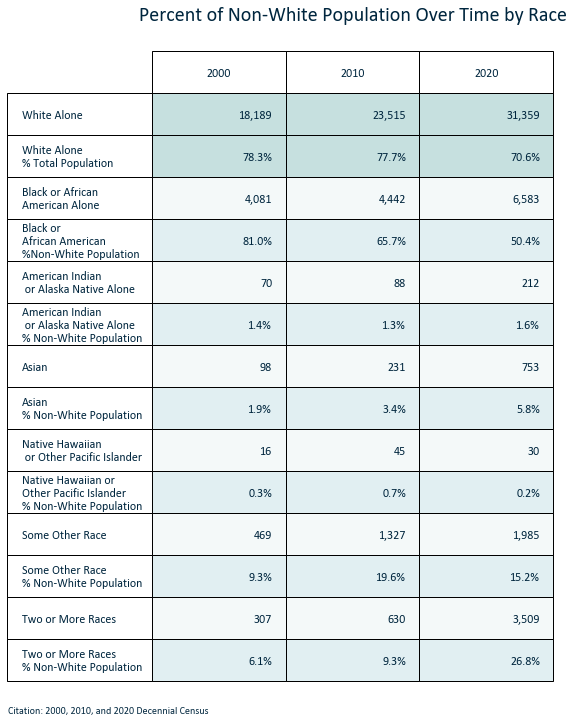

In [220]:
citation = alldecennial #set the citation
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[df_temp['Year'] != 0.0]
df_temp = df_temp[['Year','White Alone', 'White Alone %','Black or African American Alone','Black or African American Alone % Non-White Population', 
                   'American Indian Alaska Native Alone','American Indian Alaska Native Alone % Non-White Population',
                   'Asian Alone','Asian Alone % Non-White Population', 
                   'Native Hawaiian Other Pacific Islander Alone','Native Hawaiian Other Pacific Islander Alone % Non-White Population',
                   'Some Other Race Alone','Some Other Race Alone % Non-White Population', 
                   'Two or More Races','Two or More Races % Non-White Population']]
elements = ['White Alone %','Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
            'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population',
            'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']
percentformatter(elements)
df_temp = df_temp.set_index('Year')
df_temp.update(df_temp[['White Alone %', 'Black or African American Alone % Non-White Population', 'American Indian Alaska Native Alone % Non-White Population',
                        'Asian Alone % Non-White Population', 'Native Hawaiian Other Pacific Islander Alone % Non-White Population', 
                        'Some Other Race Alone % Non-White Population', 'Two or More Races % Non-White Population']].applymap('{:,.1f}%'.format))
df_temp.update(df_temp[['White Alone', 'Black or African American Alone', 'American Indian Alaska Native Alone',
                        'Asian Alone', 'Native Hawaiian Other Pacific Islander Alone', 
                        'Some Other Race Alone', 'Two or More Races']].applymap('{:,.0f}'.format))
df_temp = df_temp.transpose()
width = 3
ycount = 14
colours = [["#C6E0DF" for x in range(width)],["#C6E0DF" for x in range(width)],["#F4F9F9" for x in range(width)],
          ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],
          ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],
          ["#E1EFF2" for x in range(width)],["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)],
          ["#F4F9F9" for x in range(width)],["#E1EFF2" for x in range(width)]]
colcolours = ["#FFFFFF" for x in range(width)]
rowcolours = ["#FFFFFF" for x in range(ycount)]
title = 'Percent of Non-White Population Over Time by Race'
#title height
y = 2.0
#initiate figure and hide axes
fig, ax = plt.subplots()
fig.patch.set_visible(False)
ax.axis('off')
ax.axis('tight')

rows = ['White Alone', 'White Alone\n% Total Population','Black or African \nAmerican Alone','Black or\nAfrican American\n%Non-White Population', 
        'American Indian\n or Alaska Native Alone', 'American Indian\n or Alaska Native Alone\n% Non-White Population',
        'Asian', 'Asian\n% Non-White Population', 'Native Hawaiian\n or Other Pacific Islander', 'Native Hawaiian or \nOther Pacific Islander\n% Non-White Population',
        'Some Other Race', 'Some Other Race\n% Non-White Population', 'Two or More Races','Two or More Races\n% Non-White Population']
cols = ['2000', '2010', '2020']
#initiate table and set parameters
table = ax.table(cellText = df_temp.values, colLabels = cols, rowLabels = rows, loc = 'center', cellColours = colours, colColours = colcolours, 
                cellLoc = 'right', rowLoc = 'left', colWidths=[0.2 for x in cols], rowColours = rowcolours)#, edges = 'horizontal')
#table.set.col(visible_edges = 'horizontal')
table.auto_set_font_size(False)
table.set_fontsize(12)
ax.set_title(label = title, y = y)
table.scale(2, 3.5)
fig.text(0.18, -.7, citation, ha='right')
#display
#table.auto_set_column_width(col=list(range(len(df_temp.columns))))
fig.savefig('gallatinfigstables/nonwhitepopovertimetable.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

## Figure Name: Ethnicity Over Time

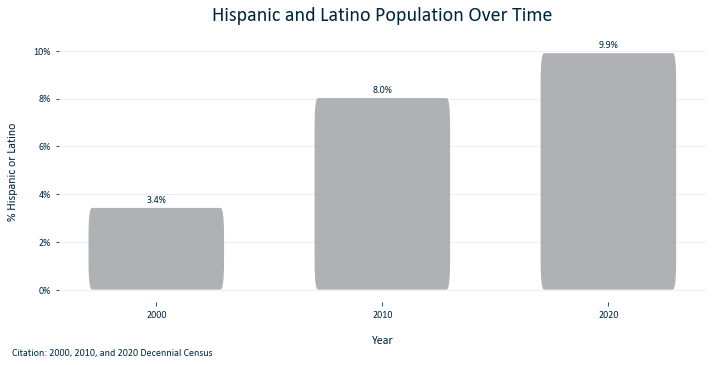

In [200]:
title = 'Hispanic and Latino Population Over Time'
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[data['Year'] != 0.0]
df_temp = df_temp.set_index('Year')
df_temp = df_temp[['Hispanic or Latino %']]
elements = ['Hispanic or Latino %']
percentformatter(elements)
df_temp.columns = ['% Hispanic or Latino']
citation = alldecennial
x1 = df_temp.index
y1 = df_temp['% Hispanic or Latino']
fig, ax = plt.subplots(figsize = figsize)
ax.bar(x1, y1, width = 6, color = '#7B7E85', alpha = 0.6, zorder = 3) 
ax.set(title = title, xlabel = 'Year', ylabel = '% Hispanic or Latino') #set the title and axes labels
#ax.xaxis.set_major_formatter(ticker.FormatStrFormatter(xaxislabelformat)) #x axis formatting
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(percentformat)) #y axis formatting
ax.yaxis.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, alpha = 0.3, color= gridcolor, zorder = 5) #major grid
#ax.set_ylim(ylimlow, ylimhigh) #y low and high limits
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
plt.locator_params(axis='x', nbins=3)
ax.set_alpha(0)
#citation label
fig.text(.3, .0009, citation, ha='right')
new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color=patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),abs(bb.width), abs(bb.height),boxstyle="round,pad=-0.002,rounding_size=0.15",
                            ec="none", fc=color,mutation_aspect=8)
    patch.remove()
    new_patches.append(p_bbox)
for patch in new_patches:
    ax.add_patch(patch) 
for j, k in zip(x1, y1):
    label = "{:,.1f}%".format(k)
    plt.annotate(label, 
                (j, k), 
                textcoords = 'offset points', 
                xytext = (0, 5), 
                ha = 'center')
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
fig.tight_layout()
fig.savefig('gallatinfigstables/hispanicorlatinonotstacked.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

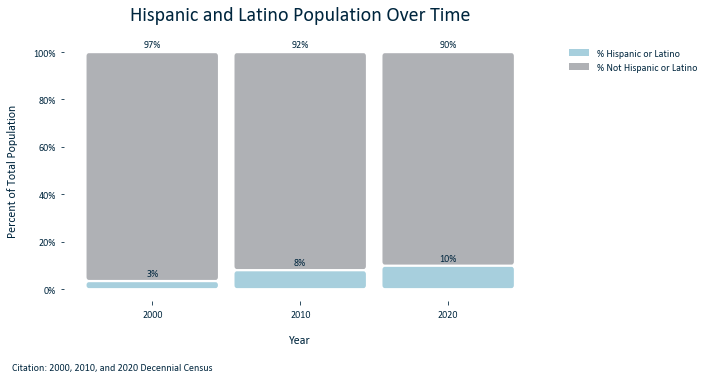

In [202]:
citation = alldecennial #set the citation
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[df_temp['Year'] != 0.0]
df_temp = df_temp[['Year','Hispanic or Latino %','Not Hispanic or Latino %']]
elements = ['Hispanic or Latino %', 'Not Hispanic or Latino %']
percentformatter(elements)
df_temp.columns = ['Year','% Hispanic or Latino', '% Not Hispanic or Latino']
#df_temp.update(df_temp[['% Hispanic or Latino', '% Not Hispanic or Latino']].applymap('{:,.1f}%'.format))
df_temp = df_temp.set_index('Year')
alpha = 0.6 #Line Transparency
fig, ax = plt.subplots(figsize = (10, 5))
w = 9
colors = ['#6DB0C7', '#7B7E85', '#F9BFB4']
bottom = np.zeros(len(df_temp))
for i, col in enumerate(df_temp.columns):
  ax.bar(df_temp.index, df_temp[col], w, bottom=bottom, label=col, color = colors[i], alpha = 0.6)
  bottom += np.array(df_temp[col])
#rounded boxes
new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color=patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),abs(bb.width), abs(bb.height),boxstyle="round,pad=-0.060,rounding_size=0.15",
                            ec="none", fc=color,mutation_aspect=8)
    patch.remove()
    new_patches.append(p_bbox)
for patch in new_patches:
    ax.add_patch(patch) 
plt.locator_params(axis='x', nbins=4)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(percentformat)) #y axis formatting
#ax.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
ax.set_alpha(0)
ax.set(title = 'Hispanic and Latino Population Over Time', xlabel = 'Year', 
       ylabel = 'Percent of Total Population') #set the title and axes labels
#citation label
fig.text(.3, -.04, citation, ha='right')
# negative offset.
y_offset = 2
# For each patch (basically each rectangle within the bar), add a label.
for bar in ax.patches:
  ax.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height() + bar.get_y() + y_offset,
      str(round(bar.get_height())) + '%',
      ha='center',
      color='#00263E',
      size=10)
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
#outside legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon = False)
fig.tight_layout()
fig.savefig('gallatinfigstables/hispanicorlatinoovertimestacked.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

## Figure Name: Minority vs. Non-Minority Population Over Time

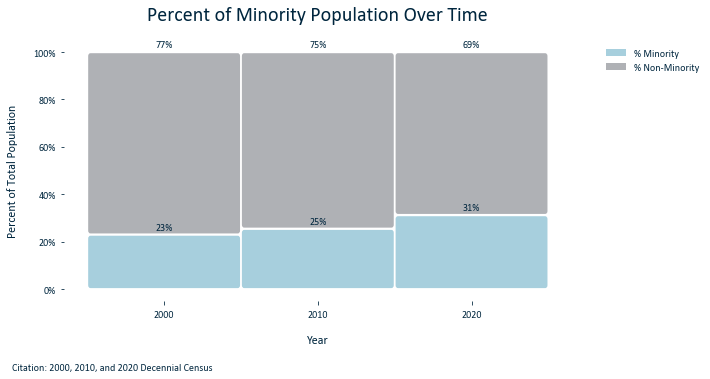

In [203]:
citation = alldecennial #set the citation
figsize = (10, 5) #set figure size
df_temp = gallatin
df_temp = df_temp.loc[df_temp['Year'] != 0.0]
df_temp = df_temp[['Year','Minority %','White Alone Not Hispanic or Latino %']]
elements = ['Minority %','White Alone Not Hispanic or Latino %']
percentformatter(elements)
df_temp.columns = ['Year','% Minority', '% Non-Minority']
#df_temp.update(df_temp[['% Hispanic or Latino', '% Not Hispanic or Latino']].applymap('{:,.1f}%'.format))
df_temp = df_temp.set_index('Year')
alpha = 0.6 #Line Transparency
fig, ax = plt.subplots(figsize = (10, 5))
w = 10
colors = ['#6DB0C7', '#7B7E85', '#F9BFB4']
bottom = np.zeros(len(df_temp))
for i, col in enumerate(df_temp.columns):
  ax.bar(df_temp.index, df_temp[col], w, bottom=bottom, label=col, color = colors[i], alpha = 0.6)
  bottom += np.array(df_temp[col])
#rounded boxes
new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color=patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),abs(bb.width), abs(bb.height),boxstyle="round,pad=-0.060,rounding_size=0.15",
                            ec="none", fc=color,mutation_aspect=8)
    patch.remove()
    new_patches.append(p_bbox)
for patch in new_patches:
    ax.add_patch(patch) 
plt.locator_params(axis='x', nbins=4)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter(yaxislabelformat)) #y axis formatting
#ax.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
ax.set_alpha(0)
ax.set(title = 'Percent of Minority Population Over Time', xlabel = 'Year', 
       ylabel = 'Percent of Total Population') #set the title and axes labels
#citation label
fig.text(.3, -.04, citation, ha='right')
### Labels for stacked bar

# negative offset.
y_offset = 2

# For each patch (basically each rectangle within the bar), add a label.
for bar in ax.patches:
  ax.text(
      # Put the text in the middle of each bar. get_x returns the start
      # so we add half the width to get to the middle.
      bar.get_x() + bar.get_width() / 2,
      # Vertically, add the height of the bar to the start of the bar,
      # along with the offset.
      bar.get_height() + bar.get_y() + y_offset,
      # This is actual value we'll show.
      str(round(bar.get_height())) + '%',
      # Center the labels and style them a bit.
      ha='center',
      color='#00263E',
      #weight='bold',
      size=10)
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
#outside legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon = False)
fig.tight_layout()
fig.savefig('gallatinfigstables/minoritypopulationovertime.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();

## Figure Title: Comparative Household Type  
family household: married couple,
family household: not married couple  
nonfamily household: householder alone  
nonfamily household: householder not alone


In [204]:
title = 'Comparative Household Type Composition'
figsize = (10, 5) #set figure size
df_temp = data.loc[data['Year'] == 2020.0]
df_temp = df_temp.set_index('NAME')
#order index for figure appearance
new_index = ['US', 'Tennessee', 'GNRC Region', 'Sumner County', 'Gallatin']
df_temp = df_temp.reindex(new_index)
citation = alldecennial #set the citation
figsize = (10, 5) #set figure size
df_temp = df_temp[['Household Type%: Family, Married Couple Households', 'Household Type%: Family, Not Married Couple Households',
                   'Household Type%: Nonfamily, Householder Alone', 'Household Type%: Nonfamily, Householder Not Alone']]
elements = ['Household Type%: Family, Married Couple Households', 'Household Type%: Family, Not Married Couple Households',
            'Household Type%: Nonfamily, Householder Alone', 'Household Type%: Nonfamily, Householder Not Alone']
percentformatter(elements)
df_temp.columns = ['Family Household: Married Couple', 'Family Households: Non-Married Couple',
                   'Nonfamily Household: Householder Alone', 'Nonfarmily Household: Householder Not Alone' ]
citation = 'Citation: 2000 and 2010 Decennial Census, 2016-2020 ACS 5 Year Estimate'

In [205]:
df_temp.head()

,Family Household: Married Couple,Family Households: Non-Married Couple,Nonfamily Household: Householder Alone,Nonfarmily Household: Householder Not Alone
NAME,,,,
US,48.062914,17.198285,27.996200,6.742601
Tennessee,48.152441,17.275422,28.572717,5.999420
GNRC Region,49.929404,16.202738,26.367814,7.500044
Sumner County,57.011973,16.042765,22.863926,4.081335
Gallatin,50.216702,18.280613,26.922828,4.579856


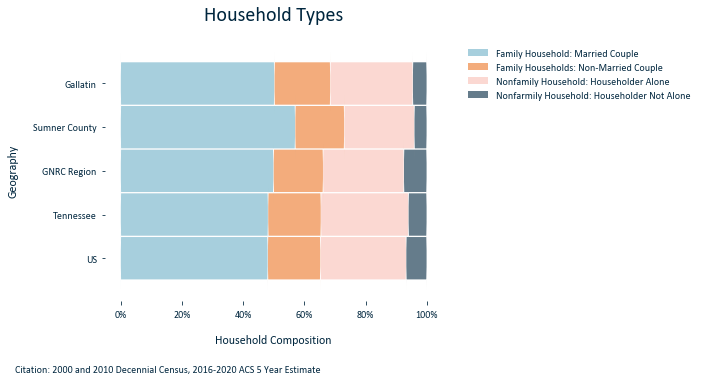

In [206]:
alpha = 0.6 #Line Transparency
fig, ax = plt.subplots(figsize = (10, 5))
w = 1.002
colors = ['#6DB0C7', '#EB7525', '#F9BFB4', '#00263E']
left = np.zeros(len(df_temp))
for i, col in enumerate(df_temp.columns):
  ax.barh(df_temp.index, df_temp[col], w, left=left, label=col, color = colors[i], alpha = 0.6)
  left += np.array(df_temp[col])
#rounded boxes
new_patches = []
for patch in reversed(ax.patches):
    bb = patch.get_bbox()
    color=patch.get_facecolor()
    p_bbox = FancyBboxPatch((bb.xmin, bb.ymin),abs(bb.width), abs(bb.height),boxstyle="round,pad=-0.0020,rounding_size=0.15",
                            ec="none", fc=color,mutation_aspect=8)
    patch.remove()
    new_patches.append(p_bbox)
for patch in new_patches:
    ax.add_patch(patch) 
# plt.locator_params(axis='y', nbins=5)
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter(percentaxisformatter)) #y axis formatting
#ax.grid(linestyle= gridlinestyle, linewidth = gridlinewidth, color= gridcolor) #major grid
ax.tick_params(axis = tickaxisselection, which = majororminortick, pad = ticklabelpadding) #tick and label params
ax.set_facecolor(color = 'None') #facecolor
ax.set_alpha(0)
ax.set(title = 'Household Types', xlabel = 'Household Composition', ylabel = 'Geography') #set the title and axes labels
#citation label
fig.text(.45, -.045, citation, ha='right')
# # negative offset.
# width_offset = 1
# # For each patch (basically each rectangle within the bar), add a label.
# for barh in ax.patches:
#   ax.text(
#       # Put the text in the middle of each bar. get_x returns the start
#       # so we add half the width to get to the middle.
#       barh.get_y() + barh.get_height() / 2,
#       # Vertically, add the height of the bar to the start of the bar,
#       # along with the offset.
#       barh.get_width() + barh.get_width() + width_offset,
#       # This is actual value we'll show.
#       round(barh.get_height()),
#       # Center the labels and style them a bit.
#       ha='center',
#       color='#00263E',
#       #weight='bold',
#       size=10)
#take away box
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
#outside legend
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon = False)
fig.tight_layout()
fig.savefig('gallatinfigstables/comparativehouseholdtype.png', bbox_inches='tight', dpi = dpi)
plt.show()
plt.close();